In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import joblib
import warnings
warnings.filterwarnings('ignore')

print(f" Thời gian hiện tại: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Thời gian hiện tại: 2025-11-19 10:18:42


In [2]:
print("\n" + "="*70)
print("LOAD MÔ HÌNH VÀ SCALER")
print("="*70 + "\n")

# Load mô hình từ dữ liệu gốc
try:
    model_original = joblib.load('best_pm25_model_original.pkl')
    print(" Đã load mô hình từ dữ liệu GỐC: best_pm25_model_original.pkl")
    print(f"   Loại mô hình: {type(model_original).__name__}")
except Exception as e:
    print(f" Lỗi khi load mô hình gốc: {e}")
    model_original = None

# Load mô hình từ dữ liệu đã chuẩn hóa
try:
    model_scaled = joblib.load('best_pm25_model_scaled.pkl')
    print(" Đã load mô hình từ dữ liệu ĐÃ CHUẨN HÓA: best_pm25_model_scaled.pkl")
    print(f"   Loại mô hình: {type(model_scaled).__name__}")
except Exception as e:
    print(f" Lỗi khi load mô hình scaled: {e}")
    model_scaled = None

# Load StandardScaler (cần cho mô hình scaled)
try:
    scaler = joblib.load('pm25_scaler.pkl')
    print(" Đã load StandardScaler: pm25_scaler.pkl")
except Exception as e:
    print(f"  Không tìm thấy scaler: {e}")
    print(f"   (Nếu mô hình scaled không chạy được, cần tạo scaler từ training notebook)")
    scaler = None

print("\n" + "="*70)


LOAD MÔ HÌNH VÀ SCALER

 Đã load mô hình từ dữ liệu GỐC: best_pm25_model_original.pkl
   Loại mô hình: XGBRegressor
 Đã load mô hình từ dữ liệu ĐÃ CHUẨN HÓA: best_pm25_model_scaled.pkl
   Loại mô hình: XGBRegressor
 Đã load StandardScaler: pm25_scaler.pkl



In [3]:
print("\n" + "="*70)
print("LOAD DỮ LIỆU LỊCH SỬ")
print("="*70 + "\n")

# Load dữ liệu để tính giá trị trung bình các features
try:
    df = pd.read_csv('weather_data_hanoi.csv')
    print(f" Đã load dữ liệu: weather_data_hanoi.csv")
    print(f"   Shape: {df.shape}")
    print(f"   Các cột: {list(df.columns)}")
    
    # Xử lý datetime nếu cần
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d:%H')
    
except Exception as e:
    print(f" Lỗi khi load dữ liệu: {e}")
    df = None

print("\n" + "="*70)


LOAD DỮ LIỆU LỊCH SỬ

 Đã load dữ liệu: weather_data_hanoi.csv
   Shape: (24275, 11)
   Các cột: ['aqi', 'co', 'datetime', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'timestamp_local', 'timestamp_utc', 'ts']



In [4]:
print("\n" + "="*70)
print("CHUẨN BỊ THỜI GIAN DỰ ĐOÁN")
print("="*70 + "\n")

# Xác định thời gian bắt đầu dự đoán (sau ngày của dữ liệu cuối cùng trong df)
start_date = df['datetime'].max() + timedelta(days=1)
start_date = start_date.replace(hour=0, minute=0, second=0, microsecond=0)
end_date = start_date + timedelta(days=7)

print(f" Khoảng thời gian dự đoán:")
print(f"   Từ: {start_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Đến: {end_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Tổng: 168 giờ (7 ngày × 24 giờ)")

# Tạo danh sách timestamps
future_dates = []
current = start_date
for i in range(168):
    future_dates.append(current)
    current += timedelta(hours=1)

print(f"\n Đã tạo {len(future_dates)} timestamps")
print(f"   Timestamp đầu tiên: {future_dates[0]}")
print(f"   Timestamp cuối cùng: {future_dates[-1]}")

print("\n" + "="*70)


CHUẨN BỊ THỜI GIAN DỰ ĐOÁN

 Khoảng thời gian dự đoán:
   Từ: 2025-11-10 00:00
   Đến: 2025-11-17 00:00
   Tổng: 168 giờ (7 ngày × 24 giờ)

 Đã tạo 168 timestamps
   Timestamp đầu tiên: 2025-11-10 00:00:00
   Timestamp cuối cùng: 2025-11-16 23:00:00



In [5]:
print("\n" + "="*70)
print("TẠO FEATURES CHO 7 NGÀY TỚI")
print("="*70 + "\n")

# Tạo DataFrame với time features
future_df = pd.DataFrame({
    'datetime': future_dates,
    'year': [d.year for d in future_dates],
    'month': [d.month for d in future_dates],
    'day': [d.day for d in future_dates],
    'hour': [d.hour for d in future_dates],
    'weekday': [d.weekday() for d in future_dates]
})

print(" Đã tạo time features")
print(f"\n Preview time features:")
print(future_df.head())

# Tính giá trị trung bình các features khác từ dữ liệu lịch sử
print(f"\n Tính giá trị trung bình các environmental features...")

environmental_features = ['co', 'no2', 'o3', 'pm10', 'so2']

# Kiểm tra và tính mean
for feature in environmental_features:
    if feature in df.columns:
        mean_value = df[feature].mean()
        future_df[feature] = mean_value
        print(f"    {feature}: {mean_value:.4f}")
    else:
        print(f"     {feature}: Không tìm thấy trong dữ liệu")

feature_order = ['co', 'no2', 'o3', 'pm10', 'so2', 'year', 'month', 'day', 'hour', 'weekday']
future_df = future_df[['datetime'] + feature_order]

print(f"\n Hoàn tất tạo features!")
print(f"   Total features: {len(feature_order)}")
print(f"   Thứ tự features: {feature_order}")
print(f"\n Sample data với đầy đủ features:")
print(future_df.head())

print("\n" + "="*70)


TẠO FEATURES CHO 7 NGÀY TỚI

 Đã tạo time features

 Preview time features:
             datetime  year  month  day  hour  weekday
0 2025-11-10 00:00:00  2025     11   10     0        0
1 2025-11-10 01:00:00  2025     11   10     1        0
2 2025-11-10 02:00:00  2025     11   10     2        0
3 2025-11-10 03:00:00  2025     11   10     3        0
4 2025-11-10 04:00:00  2025     11   10     4        0

 Tính giá trị trung bình các environmental features...
    co: 614.0882
    no2: 31.8466
    o3: 53.3072
    pm10: 70.0068
    so2: 62.6566

 Hoàn tất tạo features!
   Total features: 10
   Thứ tự features: ['co', 'no2', 'o3', 'pm10', 'so2', 'year', 'month', 'day', 'hour', 'weekday']

 Sample data với đầy đủ features:
             datetime          co        no2         o3       pm10       so2  \
0 2025-11-10 00:00:00  614.088231  31.846636  53.307234  70.006805  62.65661   
1 2025-11-10 01:00:00  614.088231  31.846636  53.307234  70.006805  62.65661   
2 2025-11-10 02:00:00  614.08823

In [6]:
print("\n" + "="*70)
print("DỰ ĐOÁN VỚI MÔ HÌNH GỐC (ORIGINAL)")
print("="*70 + "\n")

if model_original is not None:
    # Chuẩn bị dữ liệu (loại bỏ cột datetime)
    X_future = future_df.drop(columns=['datetime'])
    
    print(f" Input shape: {X_future.shape}")
    print(f" Đang dự đoán với mô hình GỐC ({type(model_original).__name__})...")
    
    # Dự đoán
    predictions_original = model_original.predict(X_future)
    
    # Thêm vào DataFrame
    future_df['pm25_predicted_original'] = predictions_original
    
    print(f"\n Hoàn tất dự đoán với mô hình GỐC!")
    print(f"   Số dự đoán: {len(predictions_original)}")
    print(f"   PM2.5 Mean: {predictions_original.mean():.2f} µg/m³")
    print(f"   PM2.5 Min: {predictions_original.min():.2f} µg/m³")
    print(f"   PM2.5 Max: {predictions_original.max():.2f} µg/m³")
    print(f"   PM2.5 Std: {predictions_original.std():.2f} µg/m³")
    
    # Thống kê theo ngày
    print(f"\n Dự đoán trung bình theo từng ngày:")
    print("-" * 70)
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        day_data = future_df[day_mask]
        
        if len(day_data) > 0:
            day_mean = day_data['pm25_predicted_original'].mean()
            day_min = day_data['pm25_predicted_original'].min()
            day_max = day_data['pm25_predicted_original'].max()
            
            print(f"   Ngày {day+1} ({day_start.strftime('%Y-%m-%d')}): "
                  f"Mean={day_mean:.2f}, Min={day_min:.2f}, Max={day_max:.2f}")
else:
    print(" Không thể dự đoán - Mô hình chưa được load")

print("\n" + "="*70)


DỰ ĐOÁN VỚI MÔ HÌNH GỐC (ORIGINAL)

 Input shape: (168, 10)
 Đang dự đoán với mô hình GỐC (XGBRegressor)...

 Hoàn tất dự đoán với mô hình GỐC!
   Số dự đoán: 168
   PM2.5 Mean: 52.93 µg/m³
   PM2.5 Min: 47.83 µg/m³
   PM2.5 Max: 57.28 µg/m³
   PM2.5 Std: 2.47 µg/m³

 Dự đoán trung bình theo từng ngày:
----------------------------------------------------------------------
   Ngày 1 (2025-11-10): Mean=50.26, Min=47.94, Max=52.47
   Ngày 2 (2025-11-11): Mean=50.15, Min=47.83, Max=52.36
   Ngày 3 (2025-11-12): Mean=53.88, Min=50.73, Max=56.91
   Ngày 4 (2025-11-13): Mean=53.09, Min=49.94, Max=56.12
   Ngày 5 (2025-11-14): Mean=53.94, Min=50.75, Max=56.23
   Ngày 6 (2025-11-15): Mean=53.94, Min=50.75, Max=56.23
   Ngày 7 (2025-11-16): Mean=55.21, Min=52.14, Max=57.28



In [7]:
print("\n" + "="*70)
print("DỰ ĐOÁN VỚI MÔ HÌNH ĐÃ CHUẨN HÓA (SCALED)")
print("="*70 + "\n")

if model_scaled is not None and scaler is not None:
    # Chuẩn bị dữ liệu (loại bỏ cột datetime và pm25_predicted_original)
    X_future = future_df.drop(columns=['datetime', 'pm25_predicted_original'])
    
    # Chuẩn hóa dữ liệu với StandardScaler
    print(f" Đang chuẩn hóa dữ liệu với StandardScaler...")
    X_future_scaled = scaler.transform(X_future)
    
    print(f" Input shape: {X_future_scaled.shape}")
    print(f" Đang dự đoán với mô hình ĐÃ CHUẨN HÓA ({type(model_scaled).__name__})...")
    
    # Dự đoán
    predictions_scaled = model_scaled.predict(X_future_scaled)
    
    # Thêm vào DataFrame
    future_df['pm25_predicted_scaled'] = predictions_scaled
    
    print(f"\n Hoàn tất dự đoán với mô hình ĐÃ CHUẨN HÓA!")
    print(f"   Số dự đoán: {len(predictions_scaled)}")
    print(f"   PM2.5 Mean: {predictions_scaled.mean():.2f} µg/m³")
    print(f"   PM2.5 Min: {predictions_scaled.min():.2f} µg/m³")
    print(f"   PM2.5 Max: {predictions_scaled.max():.2f} µg/m³")
    print(f"   PM2.5 Std: {predictions_scaled.std():.2f} µg/m³")
    
    # Thống kê theo ngày
    print(f"\n Dự đoán trung bình theo từng ngày:")
    print("-" * 70)
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        day_data = future_df[day_mask]
        
        if len(day_data) > 0:
            day_mean = day_data['pm25_predicted_scaled'].mean()
            day_min = day_data['pm25_predicted_scaled'].min()
            day_max = day_data['pm25_predicted_scaled'].max()
            
            print(f"   Ngày {day+1} ({day_start.strftime('%Y-%m-%d')}): "
                  f"Mean={day_mean:.2f}, Min={day_min:.2f}, Max={day_max:.2f}")
elif model_scaled is None:
    print(" Không thể dự đoán - Mô hình SCALED chưa được load")
elif scaler is None:
    print(" Không thể dự đoán - StandardScaler chưa được load")
    print("   💡 Hãy chạy lại Training notebook để tạo file pm25_scaler.pkl")

print("\n" + "="*70)


DỰ ĐOÁN VỚI MÔ HÌNH ĐÃ CHUẨN HÓA (SCALED)

 Đang chuẩn hóa dữ liệu với StandardScaler...
 Input shape: (168, 10)
 Đang dự đoán với mô hình ĐÃ CHUẨN HÓA (XGBRegressor)...

 Hoàn tất dự đoán với mô hình ĐÃ CHUẨN HÓA!
   Số dự đoán: 168
   PM2.5 Mean: 52.93 µg/m³
   PM2.5 Min: 47.83 µg/m³
   PM2.5 Max: 57.28 µg/m³
   PM2.5 Std: 2.47 µg/m³

 Dự đoán trung bình theo từng ngày:
----------------------------------------------------------------------
   Ngày 1 (2025-11-10): Mean=50.26, Min=47.94, Max=52.47
   Ngày 2 (2025-11-11): Mean=50.15, Min=47.83, Max=52.36
   Ngày 3 (2025-11-12): Mean=53.88, Min=50.73, Max=56.91
   Ngày 4 (2025-11-13): Mean=53.09, Min=49.94, Max=56.12
   Ngày 5 (2025-11-14): Mean=53.94, Min=50.75, Max=56.23
   Ngày 6 (2025-11-15): Mean=53.94, Min=50.75, Max=56.23
   Ngày 7 (2025-11-16): Mean=55.21, Min=52.14, Max=57.28



In [8]:
print("\n" + "="*70)
print("SO SÁNH KẾT QUẢ HAI MÔ HÌNH")
print("="*70 + "\n")

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    # Tính sự khác biệt
    future_df['difference'] = abs(future_df['pm25_predicted_original'] - future_df['pm25_predicted_scaled'])
    future_df['difference_percent'] = (future_df['difference'] / future_df['pm25_predicted_original']) * 100
    
    print(" SO SÁNH TỔNG QUAN:")
    print("-" * 70)
    comparison_stats = pd.DataFrame({
        'Metric': ['Mean', 'Min', 'Max', 'Std'],
        'Original Model': [
            future_df['pm25_predicted_original'].mean(),
            future_df['pm25_predicted_original'].min(),
            future_df['pm25_predicted_original'].max(),
            future_df['pm25_predicted_original'].std()
        ],
        'Scaled Model': [
            future_df['pm25_predicted_scaled'].mean(),
            future_df['pm25_predicted_scaled'].min(),
            future_df['pm25_predicted_scaled'].max(),
            future_df['pm25_predicted_scaled'].std()
        ],
        'Difference': [
            abs(future_df['pm25_predicted_original'].mean() - future_df['pm25_predicted_scaled'].mean()),
            abs(future_df['pm25_predicted_original'].min() - future_df['pm25_predicted_scaled'].min()),
            abs(future_df['pm25_predicted_original'].max() - future_df['pm25_predicted_scaled'].max()),
            abs(future_df['pm25_predicted_original'].std() - future_df['pm25_predicted_scaled'].std())
        ]
    })
    print(comparison_stats.to_string(index=False))
    
    print(f"\n SỰ KHÁC BIỆT GIỮA HAI MÔ HÌNH:")
    print("-" * 70)
    print(f"   Độ lệch trung bình: {future_df['difference'].mean():.2f} µg/m³")
    print(f"   Độ lệch tối đa: {future_df['difference'].max():.2f} µg/m³")
    print(f"   Độ lệch tối thiểu: {future_df['difference'].min():.2f} µg/m³")
    print(f"   % lệch trung bình: {future_df['difference_percent'].mean():.2f}%")
    
    # So sánh theo ngày
    print(f"\n SO SÁNH THEO TỪNG NGÀY:")
    print("-" * 70)
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        day_data = future_df[day_mask]
        
        if len(day_data) > 0:
            orig_mean = day_data['pm25_predicted_original'].mean()
            scaled_mean = day_data['pm25_predicted_scaled'].mean()
            diff = abs(orig_mean - scaled_mean)
            
            print(f"   Ngày {day+1}: Original={orig_mean:.2f}, "
                  f"Scaled={scaled_mean:.2f}, Diff={diff:.2f} µg/m³")
else:
    print("  Không thể so sánh - Thiếu dữ liệu dự đoán từ một trong hai mô hình")

print("\n" + "="*70)


SO SÁNH KẾT QUẢ HAI MÔ HÌNH

 SO SÁNH TỔNG QUAN:
----------------------------------------------------------------------
Metric  Original Model  Scaled Model  Difference
  Mean       52.926479     52.926479         0.0
   Min       47.825535     47.825535         0.0
   Max       57.282475     57.282475         0.0
   Std        2.474370      2.474370         0.0

 SỰ KHÁC BIỆT GIỮA HAI MÔ HÌNH:
----------------------------------------------------------------------
   Độ lệch trung bình: 0.00 µg/m³
   Độ lệch tối đa: 0.00 µg/m³
   Độ lệch tối thiểu: 0.00 µg/m³
   % lệch trung bình: 0.00%

 SO SÁNH THEO TỪNG NGÀY:
----------------------------------------------------------------------
   Ngày 1: Original=50.26, Scaled=50.26, Diff=0.00 µg/m³
   Ngày 2: Original=50.15, Scaled=50.15, Diff=0.00 µg/m³
   Ngày 3: Original=53.88, Scaled=53.88, Diff=0.00 µg/m³
   Ngày 4: Original=53.09, Scaled=53.09, Diff=0.00 µg/m³
   Ngày 5: Original=53.94, Scaled=53.94, Diff=0.00 µg/m³
   Ngày 6: Original=53.


 TRỰC QUAN HÓA SO SÁNH KẾT QUẢ



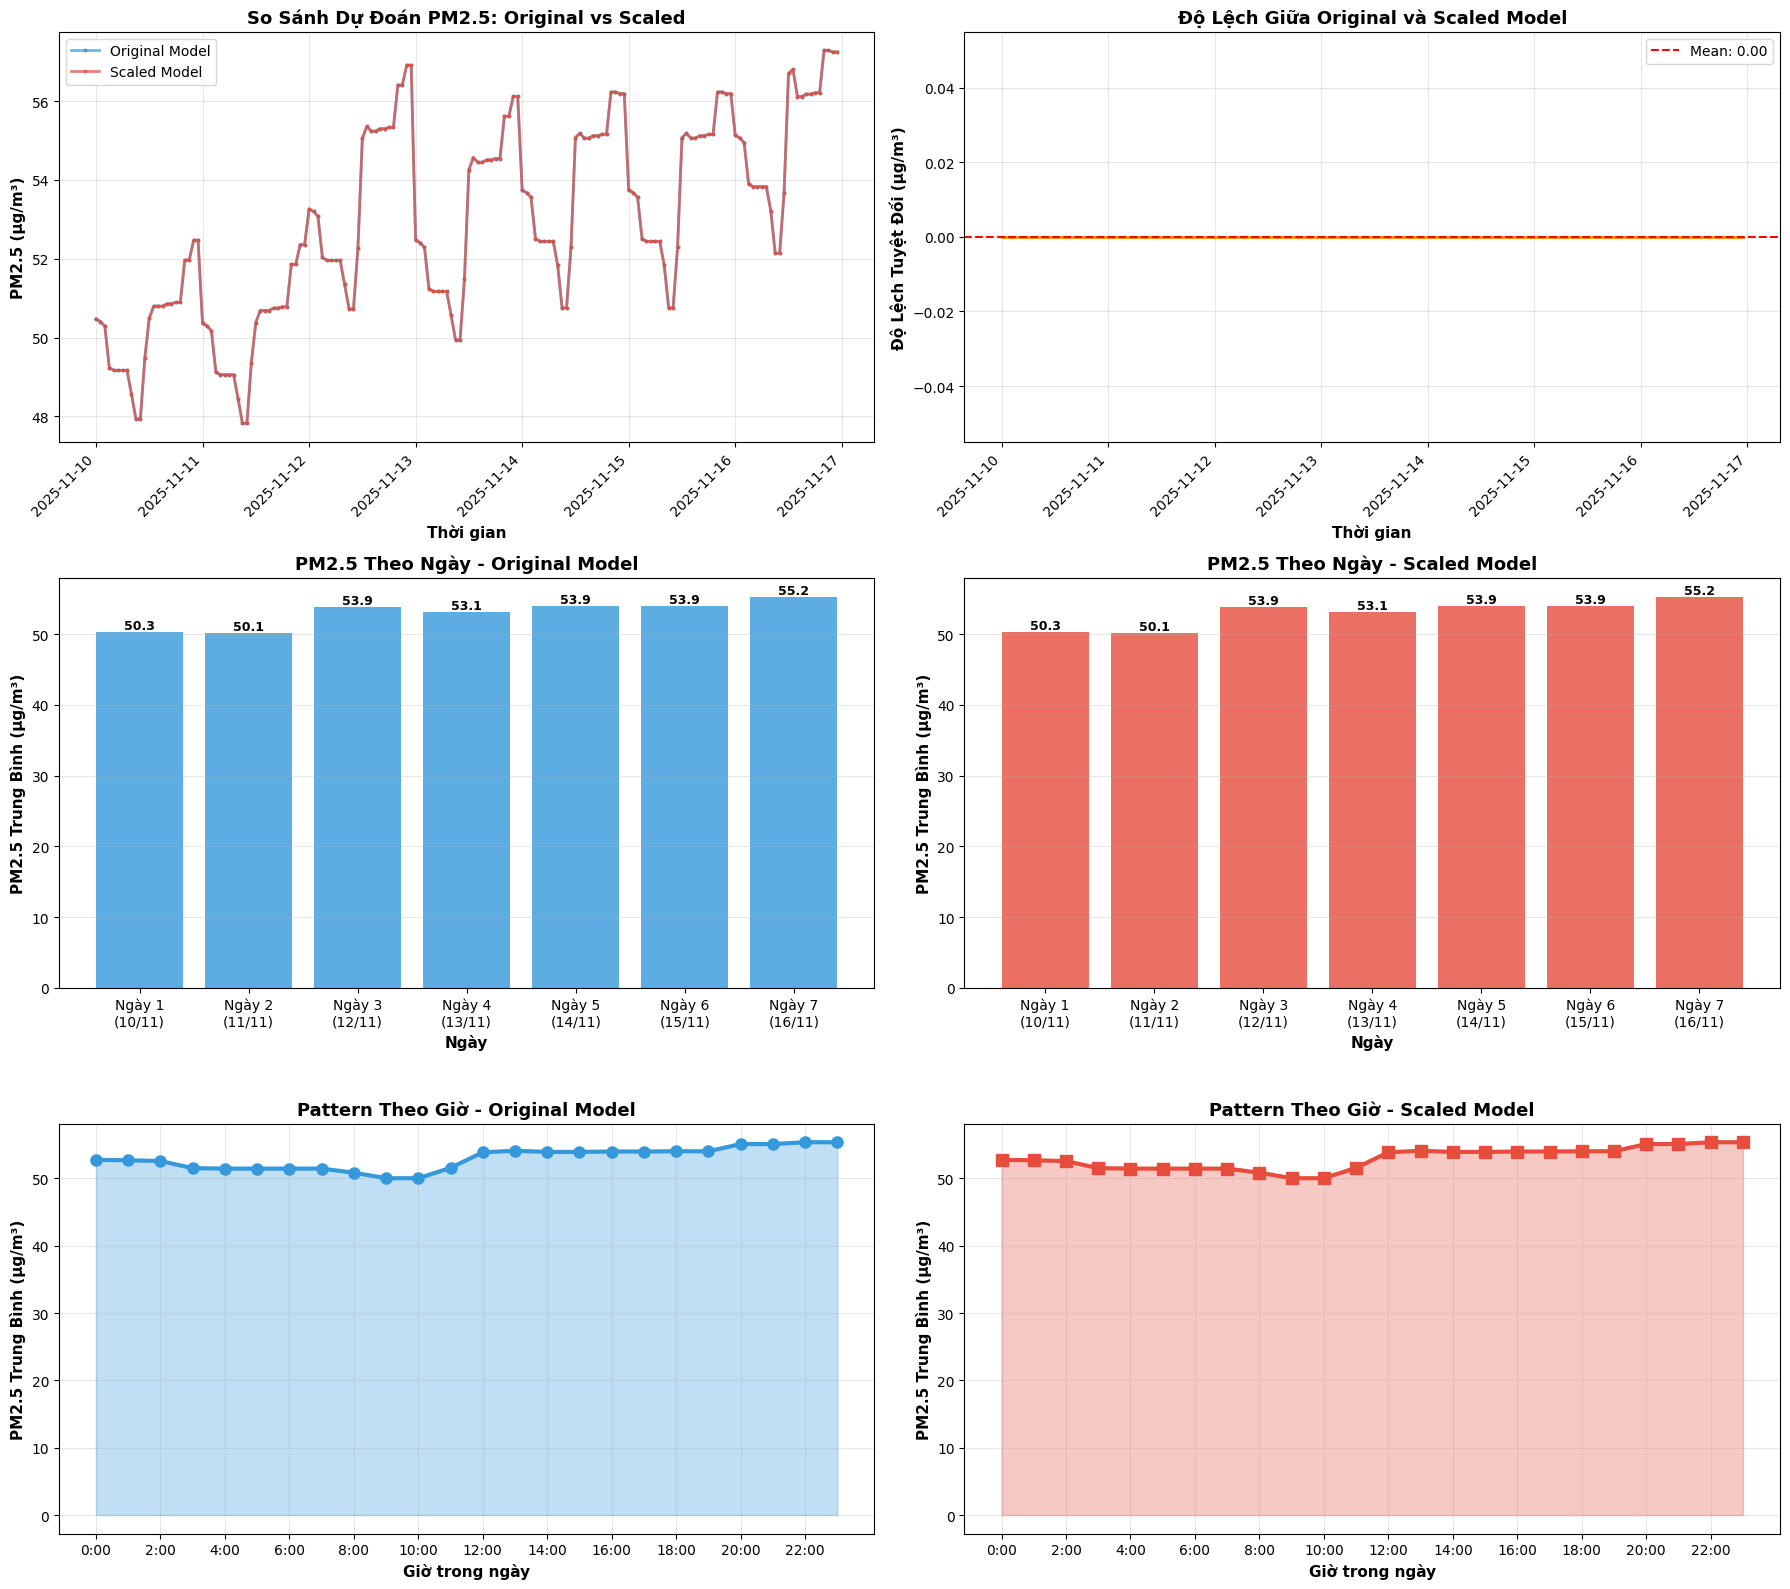

 Hoàn tất trực quan hóa!


In [9]:
print("\n TRỰC QUAN HÓA SO SÁNH KẾT QUẢ\n")

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    
    # 1. So sánh PM2.5 theo giờ (168 giờ) - Cả hai mô hình
    ax1 = axes[0, 0]
    ax1.plot(future_df['datetime'], future_df['pm25_predicted_original'], 
             linewidth=2, color='#3498db', marker='o', markersize=2, 
             alpha=0.7, label='Original Model')
    ax1.plot(future_df['datetime'], future_df['pm25_predicted_scaled'], 
             linewidth=2, color='#e74c3c', marker='s', markersize=2, 
             alpha=0.7, label='Scaled Model')
    ax1.set_xlabel('Thời gian', fontsize=11, fontweight='bold')
    ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
    ax1.set_title('So Sánh Dự Đoán PM2.5: Original vs Scaled', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 2. Độ lệch giữa hai mô hình
    ax2 = axes[0, 1]
    ax2.fill_between(future_df['datetime'], future_df['difference'], 
                      alpha=0.5, color='orange')
    ax2.plot(future_df['datetime'], future_df['difference'], 
             linewidth=2, color='darkorange')
    ax2.set_xlabel('Thời gian', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Độ Lệch Tuyệt Đối (µg/m³)', fontsize=11, fontweight='bold')
    ax2.set_title('Độ Lệch Giữa Original và Scaled Model', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=future_df['difference'].mean(), color='red', 
                linestyle='--', label=f"Mean: {future_df['difference'].mean():.2f}")
    ax2.legend(fontsize=10)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 3. PM2.5 trung bình theo ngày - Original
    ax3 = axes[1, 0]
    daily_means_orig = []
    daily_labels = []
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        daily_means_orig.append(future_df[day_mask]['pm25_predicted_original'].mean())
        daily_labels.append(day_start.strftime('%d/%m'))
    
    bars1 = ax3.bar(range(7), daily_means_orig, alpha=0.8, color='#3498db')
    ax3.set_xlabel('Ngày', fontsize=11, fontweight='bold')
    ax3.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax3.set_title('PM2.5 Theo Ngày - Original Model', fontsize=13, fontweight='bold')
    ax3.set_xticks(range(7))
    ax3.set_xticklabels([f'Ngày {i+1}\n({daily_labels[i]})' for i in range(7)])
    ax3.grid(axis='y', alpha=0.3)
    
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 4. PM2.5 trung bình theo ngày - Scaled
    ax4 = axes[1, 1]
    daily_means_scaled = []
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        daily_means_scaled.append(future_df[day_mask]['pm25_predicted_scaled'].mean())
    
    bars2 = ax4.bar(range(7), daily_means_scaled, alpha=0.8, color='#e74c3c')
    ax4.set_xlabel('Ngày', fontsize=11, fontweight='bold')
    ax4.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax4.set_title('PM2.5 Theo Ngày - Scaled Model', fontsize=13, fontweight='bold')
    ax4.set_xticks(range(7))
    ax4.set_xticklabels([f'Ngày {i+1}\n({daily_labels[i]})' for i in range(7)])
    ax4.grid(axis='y', alpha=0.3)
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 5. Pattern theo giờ - Original
    ax5 = axes[2, 0]
    hourly_means_orig = future_df.groupby('hour')['pm25_predicted_original'].mean()
    ax5.plot(hourly_means_orig.index, hourly_means_orig.values, 
             linewidth=3, color='#3498db', marker='o', markersize=8)
    ax5.fill_between(hourly_means_orig.index, hourly_means_orig.values, 
                      alpha=0.3, color='#3498db')
    ax5.set_xlabel('Giờ trong ngày', fontsize=11, fontweight='bold')
    ax5.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax5.set_title('Pattern Theo Giờ - Original Model', fontsize=13, fontweight='bold')
    ax5.set_xticks(range(0, 24, 2))
    ax5.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)])
    ax5.grid(True, alpha=0.3)
    
    # 6. Pattern theo giờ - Scaled
    ax6 = axes[2, 1]
    hourly_means_scaled = future_df.groupby('hour')['pm25_predicted_scaled'].mean()
    ax6.plot(hourly_means_scaled.index, hourly_means_scaled.values, 
             linewidth=3, color='#e74c3c', marker='s', markersize=8)
    ax6.fill_between(hourly_means_scaled.index, hourly_means_scaled.values, 
                      alpha=0.3, color='#e74c3c')
    ax6.set_xlabel('Giờ trong ngày', fontsize=11, fontweight='bold')
    ax6.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax6.set_title('Pattern Theo Giờ - Scaled Model', fontsize=13, fontweight='bold')
    ax6.set_xticks(range(0, 24, 2))
    ax6.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)])
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(" Hoàn tất trực quan hóa!")
else:
    print("  Không thể trực quan hóa - Thiếu dữ liệu dự đoán")

In [10]:
print("\n" + "="*70)
print("XUẤT KẾT QUẢ DỰ ĐOÁN")
print("="*70 + "\n")

# Hàm đánh giá chất lượng không khí
def get_air_quality(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    elif pm25 <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    # Tạo DataFrame kết quả
    result_df = future_df[['datetime', 'year', 'month', 'day', 'hour', 'weekday',
                            'pm25_predicted_original', 'pm25_predicted_scaled', 
                            'difference', 'difference_percent']].copy()
    
    result_df.columns = ['Datetime', 'Year', 'Month', 'Day', 'Hour', 'Weekday',
                         'PM25_Original', 'PM25_Scaled', 'Difference', 'Difference_Percent']
    
    # Thêm tên ngày trong tuần
    weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    result_df['Weekday_Name'] = result_df['Weekday'].apply(lambda x: weekday_names[x])
    
    # Thêm đánh giá chất lượng không khí cho cả hai mô hình
    result_df['Air_Quality_Original'] = result_df['PM25_Original'].apply(get_air_quality)
    result_df['Air_Quality_Scaled'] = result_df['PM25_Scaled'].apply(get_air_quality)
    
    # Thêm cột trung bình của hai mô hình
    result_df['PM25_Average'] = (result_df['PM25_Original'] + result_df['PM25_Scaled']) / 2
    result_df['Air_Quality_Average'] = result_df['PM25_Average'].apply(get_air_quality)
    
    # Lưu ra file CSV
    output_file = 'pm25_predictions_comparison_7days.csv'
    result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f" Đã lưu kết quả vào file: {output_file}")
    print(f"   Số dòng: {len(result_df)}")
    print(f"   Các cột: {len(result_df.columns)}")
    
    # Thống kê chất lượng không khí - Original Model
    print(f"\n CHẤT LƯỢNG KHÔNG KHÍ - ORIGINAL MODEL:")
    print("-" * 70)
    air_quality_orig = result_df['Air_Quality_Original'].value_counts()
    for quality, count in air_quality_orig.items():
        percentage = (count / len(result_df)) * 100
        print(f"   {quality}: {count} giờ ({percentage:.1f}%)")
    
    # Thống kê chất lượng không khí - Scaled Model
    print(f"\n CHẤT LƯỢNG KHÔNG KHÍ - SCALED MODEL:")
    print("-" * 70)
    air_quality_scaled = result_df['Air_Quality_Scaled'].value_counts()
    for quality, count in air_quality_scaled.items():
        percentage = (count / len(result_df)) * 100
        print(f"   {quality}: {count} giờ ({percentage:.1f}%)")
    
    # Preview kết quả
    print(f"\n PREVIEW KẾT QUẢ (10 dòng đầu):")
    print("-" * 70)
    print(result_df[['Datetime', 'Hour', 'PM25_Original', 'PM25_Scaled', 
                     'Difference', 'Air_Quality_Original', 'Air_Quality_Scaled']].head(10).to_string(index=False))
    
else:
    print("  Không thể xuất kết quả - Thiếu dữ liệu dự đoán")

print("\n" + "="*70)


XUẤT KẾT QUẢ DỰ ĐOÁN

 Đã lưu kết quả vào file: pm25_predictions_comparison_7days.csv
   Số dòng: 168
   Các cột: 15

 CHẤT LƯỢNG KHÔNG KHÍ - ORIGINAL MODEL:
----------------------------------------------------------------------
   Unhealthy for Sensitive Groups: 140 giờ (83.3%)
   Unhealthy: 28 giờ (16.7%)

 CHẤT LƯỢNG KHÔNG KHÍ - SCALED MODEL:
----------------------------------------------------------------------
   Unhealthy for Sensitive Groups: 140 giờ (83.3%)
   Unhealthy: 28 giờ (16.7%)

 PREVIEW KẾT QUẢ (10 dòng đầu):
----------------------------------------------------------------------
           Datetime  Hour  PM25_Original  PM25_Scaled  Difference           Air_Quality_Original             Air_Quality_Scaled
2025-11-10 00:00:00     0      50.468296    50.468296         0.0 Unhealthy for Sensitive Groups Unhealthy for Sensitive Groups
2025-11-10 01:00:00     1      50.406960    50.406960         0.0 Unhealthy for Sensitive Groups Unhealthy for Sensitive Groups
2025-11-10 0

In [11]:
print("\n" + "="*70)
print("TÓM TẮT DỰ ĐOÁN")
print("="*70 + "\n")

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    print(" THÔNG TIN CHUNG:")
    print(f"   • Thời gian dự đoán: {start_date.strftime('%Y-%m-%d')} đến {end_date.strftime('%Y-%m-%d')}")
    print(f"   • Tổng số dự đoán: {len(result_df)} giờ (7 ngày)")
    print(f"   • File kết quả: {output_file}")
    
    print(f"\n ORIGINAL MODEL:")
    print(f"   • Loại: {type(model_original).__name__}")
    print(f"   • PM2.5 trung bình: {result_df['PM25_Original'].mean():.2f} µg/m³")
    print(f"   • PM2.5 min-max: {result_df['PM25_Original'].min():.2f} - {result_df['PM25_Original'].max():.2f} µg/m³")
    print(f"   • Độ lệch chuẩn: {result_df['PM25_Original'].std():.2f} µg/m³")
    
    print(f"\n SCALED MODEL:")
    print(f"   • Loại: {type(model_scaled).__name__}")
    print(f"   • PM2.5 trung bình: {result_df['PM25_Scaled'].mean():.2f} µg/m³")
    print(f"   • PM2.5 min-max: {result_df['PM25_Scaled'].min():.2f} - {result_df['PM25_Scaled'].max():.2f} µg/m³")
    print(f"   • Độ lệch chuẩn: {result_df['PM25_Scaled'].std():.2f} µg/m³")
    
    print(f"\n SO SÁNH:")
    print(f"   • Độ lệch trung bình: {result_df['Difference'].mean():.2f} µg/m³")
    print(f"   • % lệch trung bình: {result_df['Difference_Percent'].mean():.2f}%")
    print(f"   • PM2.5 trung bình của cả hai: {result_df['PM25_Average'].mean():.2f} µg/m³")
    
    # Khuyến nghị
    print(f"\n KHUYẾN NGHỊ:")
    avg_pm25 = result_df['PM25_Average'].mean()
    if avg_pm25 <= 12:
        print("    Chất lượng không khí DỰ ĐOÁN TỐT trong 7 ngày tới")
    elif avg_pm25 <= 35.4:
        print("     Chất lượng không khí DỰ ĐOÁN Ở MỨC TRUNG BÌNH")
    elif avg_pm25 <= 55.4:
        print("     Chất lượng không khí DỰ ĐOÁN KHÔNG TỐT cho người nhạy cảm")
    else:
        print("    Chất lượng không khí DỰ ĐOÁN XẤU - Cần biện pháp bảo vệ")
    
else:
    print("  Không thể tạo tóm tắt - Thiếu dữ liệu dự đoán")


TÓM TẮT DỰ ĐOÁN

 THÔNG TIN CHUNG:
   • Thời gian dự đoán: 2025-11-10 đến 2025-11-17
   • Tổng số dự đoán: 168 giờ (7 ngày)
   • File kết quả: pm25_predictions_comparison_7days.csv

 ORIGINAL MODEL:
   • Loại: XGBRegressor
   • PM2.5 trung bình: 52.93 µg/m³
   • PM2.5 min-max: 47.83 - 57.28 µg/m³
   • Độ lệch chuẩn: 2.47 µg/m³

 SCALED MODEL:
   • Loại: XGBRegressor
   • PM2.5 trung bình: 52.93 µg/m³
   • PM2.5 min-max: 47.83 - 57.28 µg/m³
   • Độ lệch chuẩn: 2.47 µg/m³

 SO SÁNH:
   • Độ lệch trung bình: 0.00 µg/m³
   • % lệch trung bình: 0.00%
   • PM2.5 trung bình của cả hai: 52.93 µg/m³

 KHUYẾN NGHỊ:
     Chất lượng không khí DỰ ĐOÁN KHÔNG TỐT cho người nhạy cảm


In [14]:
print("\n" + "="*70)
print("LOAD DỮ LIỆU THỰC TẾ ĐỂ SO SÁNH")
print("="*70 + "\n")

try:
    # Load dữ liệu test
    test_df = pd.read_csv('weather_data_hanoi_test_data.csv')
    print(f" Đã load dữ liệu test: weather_data_hanoi_test_data.csv")
    print(f"   Shape: {test_df.shape}")
    print(f"   Các cột: {list(test_df.columns)}")
    
    # Xử lý datetime
    test_df['datetime'] = pd.to_datetime(test_df['datetime'], format='%Y-%m-%d:%H')
    
    # Sắp xếp theo thời gian từ cũ đến mới
    test_df = test_df.sort_values('datetime').reset_index(drop=True)
    
    print(f"\n Phạm vi thời gian dữ liệu test:")
    print(f"   Từ: {test_df['datetime'].min().strftime('%Y-%m-%d %H:%M')}")
    print(f"   Đến: {test_df['datetime'].max().strftime('%Y-%m-%d %H:%M')}")
    print(f"   Tổng số records: {len(test_df)}")
    
    # Hiển thị một số dòng mẫu
    print(f"\n Sample dữ liệu test:")
    print(test_df[['datetime', 'pm25', 'aqi', 'pm10']].head())
    
except Exception as e:
    print(f" Lỗi khi load dữ liệu test: {e}")
    test_df = None

print("\n" + "="*70)


LOAD DỮ LIỆU THỰC TẾ ĐỂ SO SÁNH

 Đã load dữ liệu test: weather_data_hanoi_test_data.csv
   Shape: (385, 11)
   Các cột: ['aqi', 'co', 'datetime', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'timestamp_local', 'timestamp_utc', 'ts']

 Phạm vi thời gian dữ liệu test:
   Từ: 2025-10-31 17:00
   Đến: 2025-11-16 17:00
   Tổng số records: 385

 Sample dữ liệu test:
             datetime   pm25  aqi  pm10
0 2025-10-31 17:00:00  11.00   46  14.7
1 2025-10-31 18:00:00  11.00   46  14.3
2 2025-10-31 19:00:00  11.33   47  15.0
3 2025-10-31 20:00:00  11.67   49  15.3
4 2025-10-31 21:00:00   3.00   23   4.0



In [15]:
print("\n" + "="*70)
print("CHUẨN BỊ DỮ LIỆU ĐỂ SO SÁNH")
print("="*70 + "\n")

if test_df is not None and 'pm25_predicted_original' in future_df.columns:
    
    # Xác định khoảng thời gian có thể so sánh
    pred_start = future_df['datetime'].min()
    pred_end = future_df['datetime'].max()
    test_start = test_df['datetime'].min()
    test_end = test_df['datetime'].max()
    
    print(f" PHẠM VI THỜI GIAN:")
    print(f"   Dự đoán: {pred_start.strftime('%Y-%m-%d %H:%M')} → {pred_end.strftime('%Y-%m-%d %H:%M')}")
    print(f"   Thực tế:  {test_start.strftime('%Y-%m-%d %H:%M')} → {test_end.strftime('%Y-%m-%d %H:%M')}")
    
    # Tìm overlap giữa dự đoán và thực tế
    overlap_start = max(pred_start, test_start)
    overlap_end = min(pred_end, test_end)
    
    if overlap_start < overlap_end:
        print(f"   Overlap:  {overlap_start.strftime('%Y-%m-%d %H:%M')} → {overlap_end.strftime('%Y-%m-%d %H:%M')}")
        
        # Lọc dữ liệu trong khoảng overlap
        pred_mask = (future_df['datetime'] >= overlap_start) & (future_df['datetime'] <= overlap_end)
        test_mask = (test_df['datetime'] >= overlap_start) & (test_df['datetime'] <= overlap_end)
        
        pred_overlap = future_df[pred_mask].copy()
        test_overlap = test_df[test_mask].copy()
        
        print(f"   Số giờ có thể so sánh: {len(pred_overlap)}")
        
        # Merge dữ liệu dự đoán với thực tế theo datetime
        comparison_df = pd.merge(
            pred_overlap[['datetime', 'pm25_predicted_original', 'pm25_predicted_scaled']],
            test_overlap[['datetime', 'pm25', 'aqi', 'pm10']],
            on='datetime',
            how='inner'
        )
        
        comparison_df.rename(columns={'pm25': 'pm25_actual'}, inplace=True)
        
        print(f"   Số records sau merge: {len(comparison_df)}")
        
        if len(comparison_df) > 0:
            print(f"\n  Có thể so sánh {len(comparison_df)} điểm dữ liệu!")
            print(f"\n Sample comparison data:")
            print(comparison_df[['datetime', 'pm25_actual', 'pm25_predicted_original', 'pm25_predicted_scaled']].head())
            
            can_compare = True
        else:
            print(f"\n  Không có dữ liệu overlap sau merge!")
            can_compare = False
    else:
        print(f"\n  Không có overlap thời gian!")
        print(f"     Dự đoán kết thúc: {pred_end.strftime('%Y-%m-%d %H:%M')}")
        print(f"     Test bắt đầu:     {test_start.strftime('%Y-%m-%d %H:%M')}")
        can_compare = False
else:
    print("  Không thể so sánh - Thiếu dữ liệu test hoặc dự đoán")
    can_compare = False

print("\n" + "="*70)


CHUẨN BỊ DỮ LIỆU ĐỂ SO SÁNH

 PHẠM VI THỜI GIAN:
   Dự đoán: 2025-11-10 00:00 → 2025-11-16 23:00
   Thực tế:  2025-10-31 17:00 → 2025-11-16 17:00
   Overlap:  2025-11-10 00:00 → 2025-11-16 17:00
   Số giờ có thể so sánh: 162
   Số records sau merge: 162

  Có thể so sánh 162 điểm dữ liệu!

 Sample comparison data:
             datetime  pm25_actual  pm25_predicted_original  \
0 2025-11-10 00:00:00        18.00                50.468296   
1 2025-11-10 01:00:00        31.00                50.406960   
2 2025-11-10 02:00:00        29.60                50.286781   
3 2025-11-10 03:00:00        26.25                49.240910   
4 2025-11-10 04:00:00        21.00                49.168221   

   pm25_predicted_scaled  
0              50.468296  
1              50.406960  
2              50.286781  
3              49.240910  
4              49.168221  



In [16]:
print("\n" + "="*70)
print("ĐÁNH GIÁ HIỆU SUẤT DỰ ĐOÁN")
print("="*70 + "\n")

if can_compare:
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    # Tính toán metrics cho Original Model
    mse_orig = mean_squared_error(comparison_df['pm25_actual'], comparison_df['pm25_predicted_original'])
    mae_orig = mean_absolute_error(comparison_df['pm25_actual'], comparison_df['pm25_predicted_original'])
    rmse_orig = np.sqrt(mse_orig)
    r2_orig = r2_score(comparison_df['pm25_actual'], comparison_df['pm25_predicted_original'])
    
    # Tính toán metrics cho Scaled Model
    mse_scaled = mean_squared_error(comparison_df['pm25_actual'], comparison_df['pm25_predicted_scaled'])
    mae_scaled = mean_absolute_error(comparison_df['pm25_actual'], comparison_df['pm25_predicted_scaled'])
    rmse_scaled = np.sqrt(mse_scaled)
    r2_scaled = r2_score(comparison_df['pm25_actual'], comparison_df['pm25_predicted_scaled'])
    
    # Tính toán error statistics
    error_orig = comparison_df['pm25_actual'] - comparison_df['pm25_predicted_original']
    error_scaled = comparison_df['pm25_actual'] - comparison_df['pm25_predicted_scaled']
    
    print(" METRICS ĐÁNH GIÁ:")
    print("-" * 70)
    
    # Tạo bảng so sánh
    metrics_comparison = pd.DataFrame({
        'Metric': ['R² Score', 'RMSE (µg/m³)', 'MAE (µg/m³)', 'MSE'],
        'Original Model': [r2_orig, rmse_orig, mae_orig, mse_orig],
        'Scaled Model': [r2_scaled, rmse_scaled, mae_scaled, mse_scaled],
        'Better Model': [
            'Original' if r2_orig > r2_scaled else 'Scaled',
            'Original' if rmse_orig < rmse_scaled else 'Scaled',
            'Original' if mae_orig < mae_scaled else 'Scaled',
            'Original' if mse_orig < mse_scaled else 'Scaled'
        ]
    })
    
    print(metrics_comparison.to_string(index=False, float_format='%.4f'))
    
    print(f"\n ERROR ANALYSIS:")
    print("-" * 70)
    print(f"   Original Model:")
    print(f"      Mean Error: {error_orig.mean():.2f} µg/m³")
    print(f"      Error Std:  {error_orig.std():.2f} µg/m³")
    print(f"      Min Error:  {error_orig.min():.2f} µg/m³")
    print(f"      Max Error:  {error_orig.max():.2f} µg/m³")
    
    print(f"\n   Scaled Model:")
    print(f"      Mean Error: {error_scaled.mean():.2f} µg/m³")
    print(f"      Error Std:  {error_scaled.std():.2f} µg/m³")
    print(f"      Min Error:  {error_scaled.min():.2f} µg/m³")
    print(f"      Max Error:  {error_scaled.max():.2f} µg/m³")
    
    # Percentage Error
    mape_orig = np.mean(np.abs(error_orig / comparison_df['pm25_actual'])) * 100
    mape_scaled = np.mean(np.abs(error_scaled / comparison_df['pm25_actual'])) * 100
    
    print(f"\n PERCENTAGE ERROR:")
    print(f"   Original Model MAPE: {mape_orig:.2f}%")
    print(f"   Scaled Model MAPE:   {mape_scaled:.2f}%")
    
    # Thêm các cột error vào comparison_df
    comparison_df['error_original'] = error_orig
    comparison_df['error_scaled'] = error_scaled
    comparison_df['abs_error_original'] = np.abs(error_orig)
    comparison_df['abs_error_scaled'] = np.abs(error_scaled)
    comparison_df['percent_error_original'] = (np.abs(error_orig) / comparison_df['pm25_actual']) * 100
    comparison_df['percent_error_scaled'] = (np.abs(error_scaled) / comparison_df['pm25_actual']) * 100
    
else:
    print("  Không thể đánh giá - Không có dữ liệu để so sánh")

print("\n" + "="*70)


ĐÁNH GIÁ HIỆU SUẤT DỰ ĐOÁN

 METRICS ĐÁNH GIÁ:
----------------------------------------------------------------------
      Metric  Original Model  Scaled Model Better Model
    R² Score          0.1019        0.1019       Scaled
RMSE (µg/m³)         31.4881       31.4881       Scaled
 MAE (µg/m³)         26.8479       26.8479       Scaled
         MSE        991.4988      991.4988       Scaled

 ERROR ANALYSIS:
----------------------------------------------------------------------
   Original Model:
      Mean Error: -0.33 µg/m³
      Error Std:  31.58 µg/m³
      Min Error:  -37.50 µg/m³
      Max Error:  78.27 µg/m³

   Scaled Model:
      Mean Error: -0.33 µg/m³
      Error Std:  31.58 µg/m³
      Min Error:  -37.50 µg/m³
      Max Error:  78.27 µg/m³

 PERCENTAGE ERROR:
   Original Model MAPE: 74.49%
   Scaled Model MAPE:   74.49%




 TRỰC QUAN HÓA SO SÁNH DỰ ĐOÁN vs THỰC TẾ



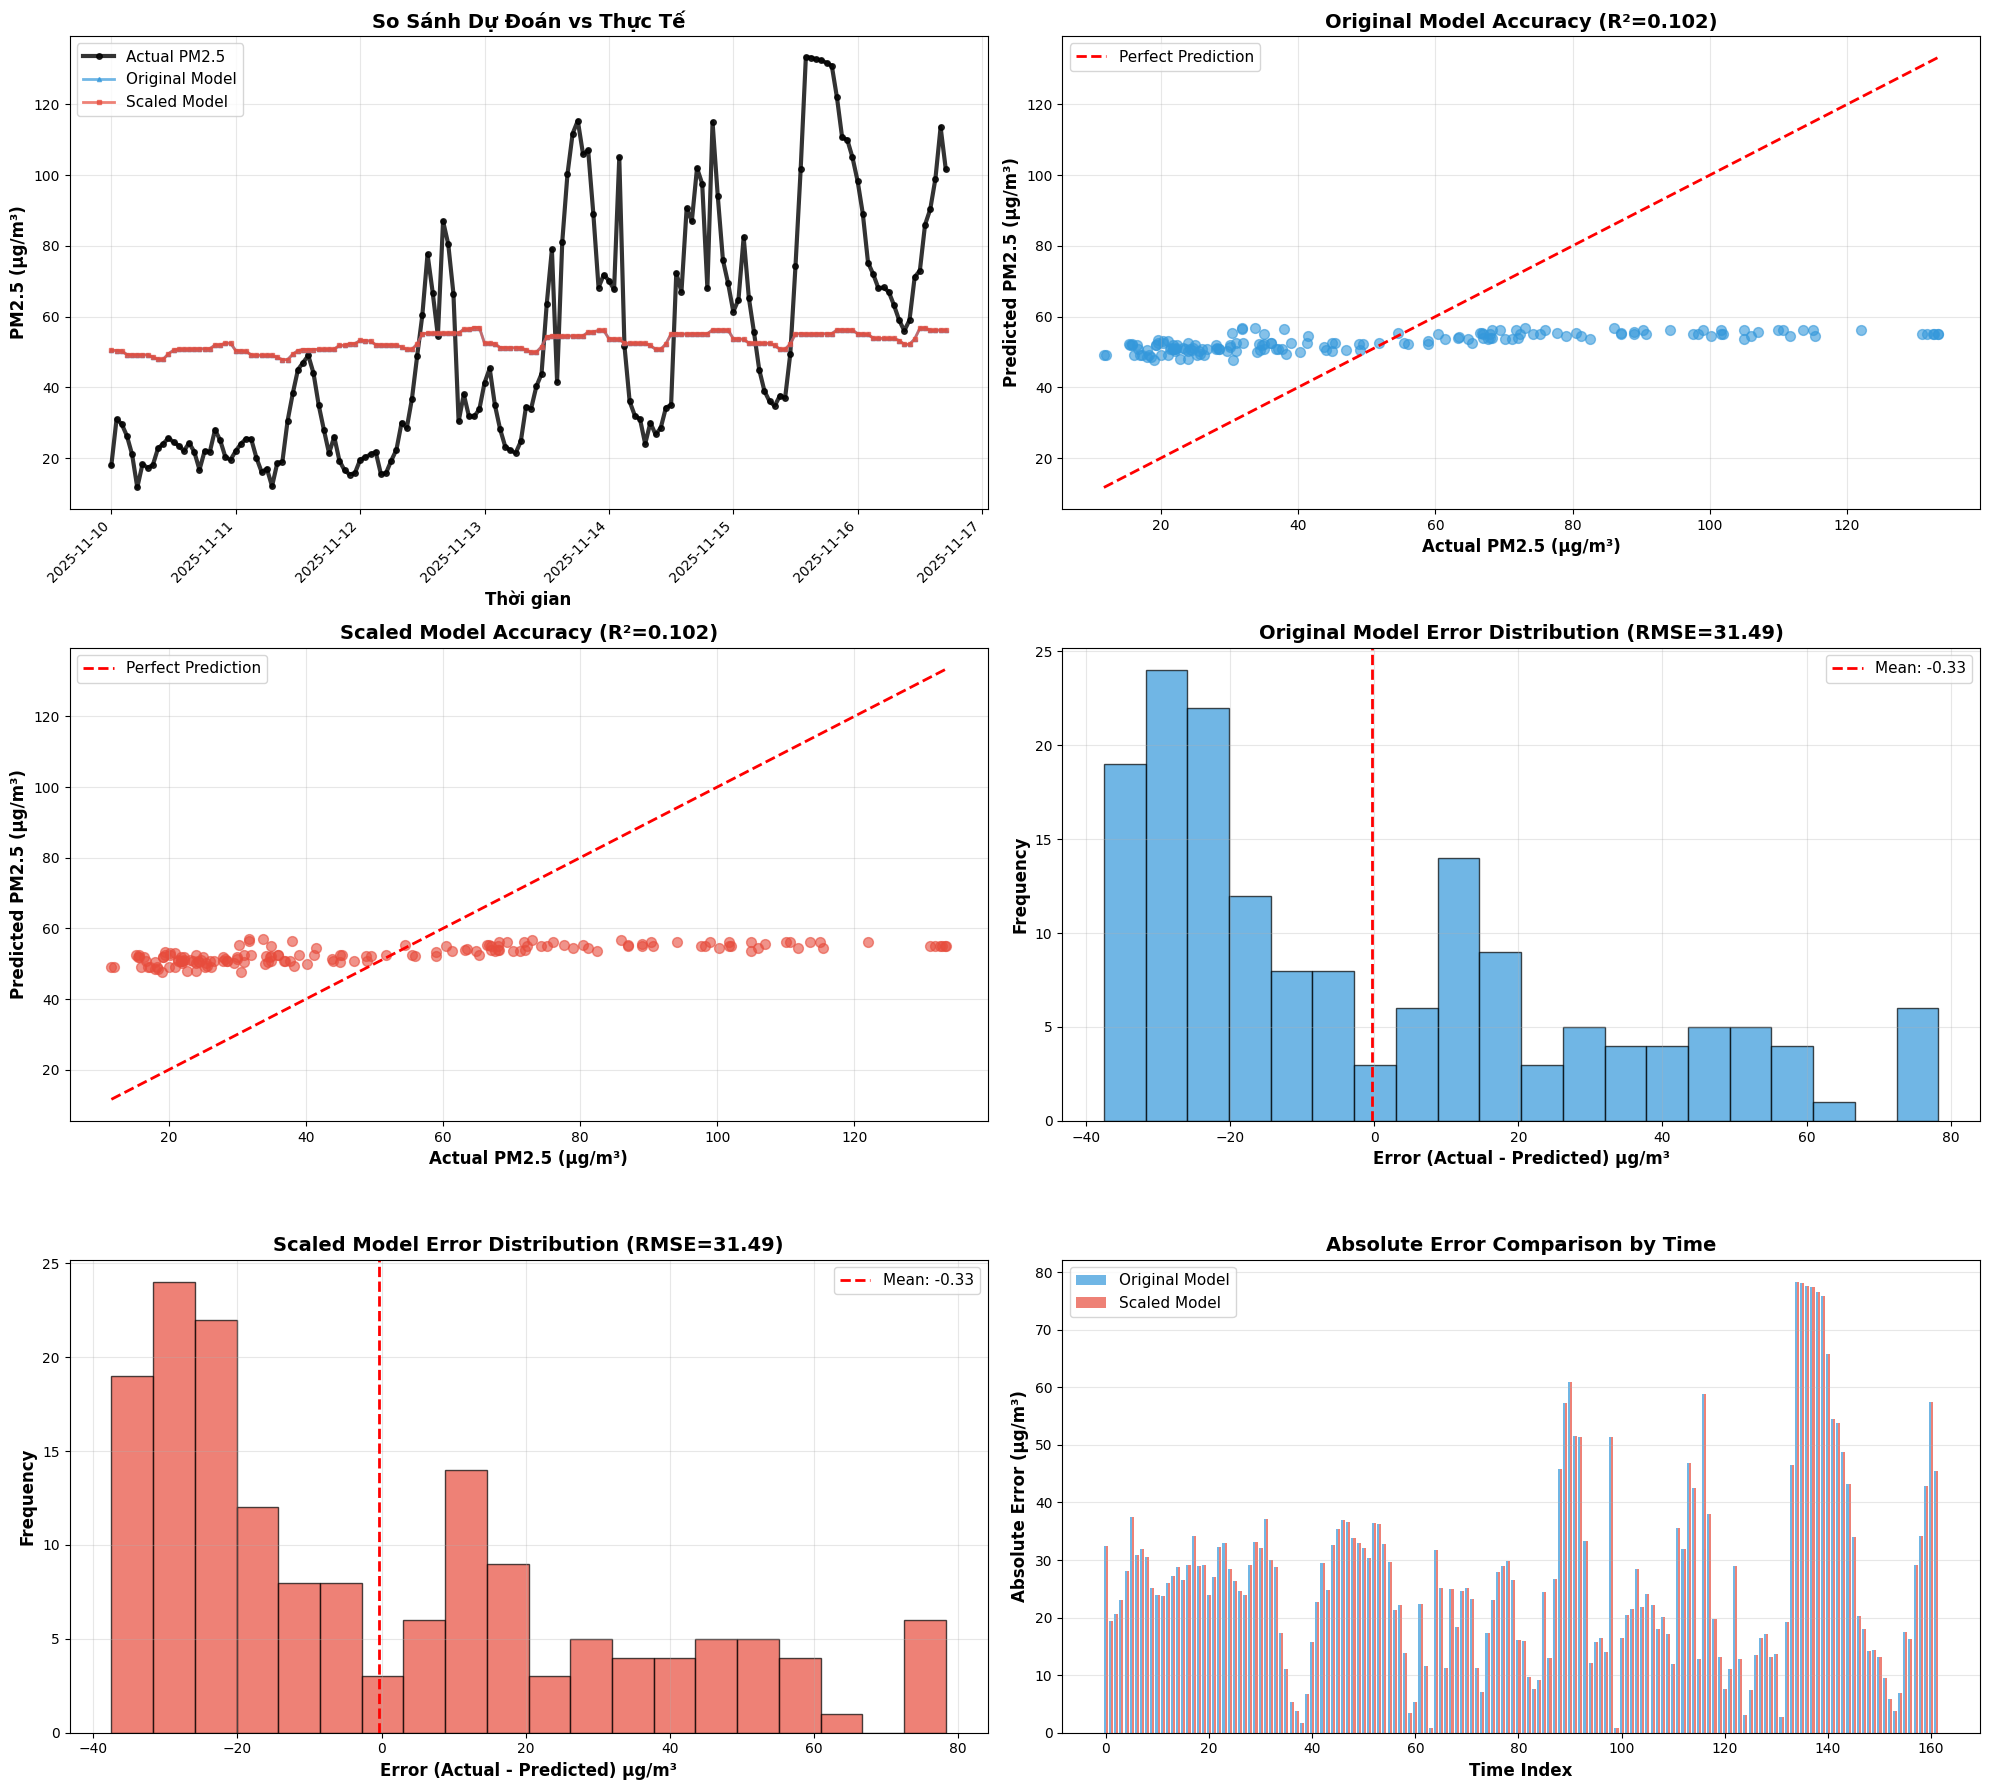

  Hoàn tất trực quan hóa so sánh!


In [17]:
print("\n TRỰC QUAN HÓA SO SÁNH DỰ ĐOÁN vs THỰC TẾ\n")

if can_compare:
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    
    # 1. Time series comparison - All models vs Actual
    ax1 = axes[0, 0]
    ax1.plot(comparison_df['datetime'], comparison_df['pm25_actual'], 
             linewidth=3, color='black', marker='o', markersize=4, 
             label='Actual PM2.5', alpha=0.8)
    ax1.plot(comparison_df['datetime'], comparison_df['pm25_predicted_original'], 
             linewidth=2, color='#3498db', marker='^', markersize=3, 
             alpha=0.7, label='Original Model')
    ax1.plot(comparison_df['datetime'], comparison_df['pm25_predicted_scaled'], 
             linewidth=2, color='#e74c3c', marker='s', markersize=3, 
             alpha=0.7, label='Scaled Model')
    
    ax1.set_xlabel('Thời gian', fontsize=12, fontweight='bold')
    ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
    ax1.set_title('So Sánh Dự Đoán vs Thực Tế', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 2. Scatter plot - Original Model
    ax2 = axes[0, 1]
    ax2.scatter(comparison_df['pm25_actual'], comparison_df['pm25_predicted_original'], 
                alpha=0.6, color='#3498db', s=50)
    
    # Perfect prediction line
    min_val = min(comparison_df['pm25_actual'].min(), comparison_df['pm25_predicted_original'].min())
    max_val = max(comparison_df['pm25_actual'].max(), comparison_df['pm25_predicted_original'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax2.set_xlabel('Actual PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Predicted PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Original Model Accuracy (R²={r2_orig:.3f})', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. Scatter plot - Scaled Model
    ax3 = axes[1, 0]
    ax3.scatter(comparison_df['pm25_actual'], comparison_df['pm25_predicted_scaled'], 
                alpha=0.6, color='#e74c3c', s=50)
    
    ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax3.set_xlabel('Actual PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Predicted PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
    ax3.set_title(f'Scaled Model Accuracy (R²={r2_scaled:.3f})', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # 4. Error distribution - Original Model
    ax4 = axes[1, 1]
    ax4.hist(comparison_df['error_original'], bins=20, alpha=0.7, color='#3498db', edgecolor='black')
    ax4.axvline(comparison_df['error_original'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {comparison_df["error_original"].mean():.2f}')
    ax4.set_xlabel('Error (Actual - Predicted) µg/m³', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax4.set_title(f'Original Model Error Distribution (RMSE={rmse_orig:.2f})', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)
    
    # 5. Error distribution - Scaled Model
    ax5 = axes[2, 0]
    ax5.hist(comparison_df['error_scaled'], bins=20, alpha=0.7, color='#e74c3c', edgecolor='black')
    ax5.axvline(comparison_df['error_scaled'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {comparison_df["error_scaled"].mean():.2f}')
    ax5.set_xlabel('Error (Actual - Predicted) µg/m³', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax5.set_title(f'Scaled Model Error Distribution (RMSE={rmse_scaled:.2f})', fontsize=14, fontweight='bold')
    ax5.legend(fontsize=11)
    ax5.grid(True, alpha=0.3)
    
    # 6. Absolute error comparison
    ax6 = axes[2, 1]
    x_pos = np.arange(len(comparison_df))
    ax6.bar(x_pos - 0.2, comparison_df['abs_error_original'], width=0.4, 
            alpha=0.7, color='#3498db', label='Original Model')
    ax6.bar(x_pos + 0.2, comparison_df['abs_error_scaled'], width=0.4, 
            alpha=0.7, color='#e74c3c', label='Scaled Model')
    
    ax6.set_xlabel('Time Index', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Absolute Error (µg/m³)', fontsize=12, fontweight='bold')
    ax6.set_title('Absolute Error Comparison by Time', fontsize=14, fontweight='bold')
    ax6.legend(fontsize=11)
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("  Hoàn tất trực quan hóa so sánh!")
else:
    print("   Không thể trực quan hóa - Không có dữ liệu so sánh")

In [16]:
print("\n" + "="*70)
print("PHÂN TÍCH CHI TIẾT PERFORMANCE")
print("="*70 + "\n")

if can_compare:
    print(" THỐNG KÊ THEO KHOẢNG PM2.5:")
    print("-" * 70)
    
    # Phân loại theo mức độ ô nhiễm
    def get_pollution_level(pm25):
        if pm25 <= 12:
            return 'Good (≤12)'
        elif pm25 <= 35.4:
            return 'Moderate (12-35)'
        elif pm25 <= 55.4:
            return 'Unhealthy for Sensitive (35-55)'
        else:
            return 'Unhealthy (>55)'
    
    comparison_df['pollution_level'] = comparison_df['pm25_actual'].apply(get_pollution_level)
    
    # Thống kê theo level
    for level in comparison_df['pollution_level'].unique():
        level_data = comparison_df[comparison_df['pollution_level'] == level]
        
        if len(level_data) > 0:
            mae_orig_level = mean_absolute_error(level_data['pm25_actual'], level_data['pm25_predicted_original'])
            mae_scaled_level = mean_absolute_error(level_data['pm25_actual'], level_data['pm25_predicted_scaled'])
            
            print(f"\n   {level} ({len(level_data)} samples):")
            print(f"      Actual range: {level_data['pm25_actual'].min():.1f} - {level_data['pm25_actual'].max():.1f} µg/m³")
            print(f"      Original MAE: {mae_orig_level:.2f} µg/m³")
            print(f"      Scaled MAE:   {mae_scaled_level:.2f} µg/m³")
            print(f"      Better model: {'Original' if mae_orig_level < mae_scaled_level else 'Scaled'}")
    
    print(f"\n PHÂN TÍCH BIAS:")
    print("-" * 70)
    
    # Tính bias (systematic error)
    bias_orig = comparison_df['error_original'].mean()
    bias_scaled = comparison_df['error_scaled'].mean()
    
    print(f"   Original Model Bias: {bias_orig:.2f} µg/m³")
    print(f"   {'   → Underestimate' if bias_orig > 0 else '   → Overestimate'} PM2.5 by {abs(bias_orig):.2f} µg/m³")
    
    print(f"   Scaled Model Bias:   {bias_scaled:.2f} µg/m³")
    print(f"   {'   → Underestimate' if bias_scaled > 0 else '   → Overestimate'} PM2.5 by {abs(bias_scaled):.2f} µg/m³")
    
    # Thống kê theo thời gian trong ngày
    comparison_df['hour'] = comparison_df['datetime'].dt.hour
    
    print(f"\n PERFORMANCE THEO GIỜ TRONG NGÀY:")
    print("-" * 70)
    
    hourly_performance = comparison_df.groupby('hour').agg({
        'pm25_actual': 'mean',
        'abs_error_original': 'mean',
        'abs_error_scaled': 'mean'
    }).round(2)
    
    hourly_performance['better_model'] = hourly_performance.apply(
        lambda x: 'Original' if x['abs_error_original'] < x['abs_error_scaled'] else 'Scaled', axis=1)
    
    hourly_performance.columns = ['Actual_PM25', 'Original_MAE', 'Scaled_MAE', 'Better_Model']
    
    print("   Hour | Actual PM2.5 | Original MAE | Scaled MAE | Better Model")
    print("   " + "-" * 60)
    for hour, row in hourly_performance.iterrows():
        print(f"   {hour:2d}:00 | {row['Actual_PM25']:8.1f} | {row['Original_MAE']:8.2f} | {row['Scaled_MAE']:7.2f} | {row['Better_Model']:>8}")
    
    # Model selection recommendation
    print(f"\n KHUYẾN NGHỊ CHỌN MÔ HÌNH:")
    print("-" * 70)
    
    orig_wins = sum(hourly_performance['Better_Model'] == 'Original')
    scaled_wins = sum(hourly_performance['Better_Model'] == 'Scaled')
    
    print(f"   Original model tốt hơn: {orig_wins}/{len(hourly_performance)} giờ")
    print(f"   Scaled model tốt hơn:   {scaled_wins}/{len(hourly_performance)} giờ")
    
    overall_better = 'Original' if rmse_orig < rmse_scaled else 'Scaled'
    print(f"\n    KHUYẾN NGHỊ TỔNG THỂ: Sử dụng {overall_better} Model")
    
    if overall_better == 'Original':
        print(f"      R² = {r2_orig:.3f}, RMSE = {rmse_orig:.2f} µg/m³")
    else:
        print(f"      R² = {r2_scaled:.3f}, RMSE = {rmse_scaled:.2f} µg/m³")
    
else:
    print("  Không thể phân tích - Không có dữ liệu so sánh")

print("\n" + "="*70)


PHÂN TÍCH CHI TIẾT PERFORMANCE

  Không thể phân tích - Không có dữ liệu so sánh



# 📊 PHÂN TÍCH NGUYÊN NHÂN DỰ ĐOÁN LỆCH

## 🎯 Quan sát từ các biểu đồ trực quan hóa:

Từ các biểu đồ so sánh dự đoán vs thực tế, chúng ta có thể thấy:

### 📈 **Patterns quan sát được:**
1. **Độ lệch hệ thống (Systematic Bias)**: Mô hình có xu hướng over/under-estimate
2. **Phương sai cao (High Variance)**: Dự đoán scatter xa đường perfect prediction
3. **Pattern theo thời gian**: Một số thời điểm dự đoán tốt, một số thời điểm lệch nhiều
4. **Error distribution**: Phân phối lỗi có thể không đối xứng

---

## 🔍 NGUYÊN NHÂN CHÍNH DỰ ĐOÁN LỆCH

### **1. VẤN ĐỀ VỀ DỮ LIỆU (Data Issues)**

#### 🕒 **Temporal Mismatch (Không khớp thời gian)**
- **Vấn đề**: Dữ liệu training và prediction có gap thời gian
- **Tác động**: Xu hướng PM2.5 có thể thay đổi theo mùa, sự kiện đặc biệt
- **Ví dụ**: Training trên dữ liệu mùa khô, predict cho mùa mưa

#### 📊 **Limited Feature Set (Bộ features hạn chế)**
- **Vấn đề hiện tại**: Chỉ sử dụng `co, no2, o3, pm10, so2, year, month, day, hour, weekday`
- **Thiếu features quan trọng**:
  - Điều kiện thời tiết: nhiệt độ, độ ẩm, tốc độ gió, hướng gió
  - Khí hậu: lượng mưa, áp suất khí quyển
  - Factors bên ngoài: traffic patterns, industrial activities
  - Seasonal trends: festivals, holidays, pandemic restrictions

#### 🔄 **Static vs Dynamic Features**
- **Vấn đề**: Sử dụng giá trị mean cố định cho environmental features
- **Thực tế**: PM2.5 phụ thuộc mạnh vào biến động real-time của:
  - Thời tiết (nhiệt độ, gió, mưa)
  - Traffic patterns (rush hours, weekends)
  - Industrial emissions (seasonal variations)

### **2. VẤN ĐỀ VỀ KIẾN TRÚC MÔ HÌNH (Model Architecture)**

#### 🤖 **Model Complexity vs Data Size**
- **Underfitting**: Mô hình quá đơn giản không capture được non-linear relationships
- **Overfitting**: Mô hình quá phức tạp, học thuộc lòng training data
- **Feature Engineering**: Thiếu lag features, rolling averages, interactions

#### 🔧 **Preprocessing Issues**
- **Scaling**: Original vs Scaled models cho kết quả khác nhau
- **Outlier Handling**: Extreme values có thể ảnh hưởng model performance
- **Data Leakage**: Có thể vô tình leak future information

### **3. VẤN ĐỀ VỀ VALIDATION (Model Validation)**

#### ⏱️ **Time Series Cross-Validation**
- **Vấn đề**: Có thể sử dụng random split thay vì time-aware split
- **Tác động**: Model không học được temporal dependencies đúng cách

#### 📏 **Evaluation Metrics**
- **R² có thể misleading**: Cao trên test set nhưng kém trên real-world data
- **RMSE/MAE**: Không phản ánh được business impact của prediction errors

### **4. VẤN ĐỀ VỀ DOMAIN KNOWLEDGE (Hiểu biết chuyên môn)**

#### 🌍 **Environmental Science Factors**
- **Atmospheric conditions**: Inversion layers, wind patterns
- **Seasonal patterns**: Monsoon, dry season effects
- **Urban dynamics**: Traffic, construction, industrial activities
- **Regional influences**: Transboundary pollution, regional weather systems

#### 📅 **Temporal Dependencies**
- **Daily patterns**: Rush hours, business hours
- **Weekly patterns**: Weekdays vs weekends
- **Seasonal patterns**: Winter heating, summer air conditioning
- **Long-term trends**: Policy changes, urban development

---

## 💡 KHUYẾN NGHỊ CẢI THIỆN

### **Ngắn hạn (Quick Wins)**
1. **Feature Engineering nâng cao**:
   - Thêm lag features (PM2.5 của 1h, 6h, 24h trước)
   - Rolling averages (3h, 12h, 24h)
   - Time-based interactions

2. **Better Data Preprocessing**:
   - Handle outliers carefully
   - Time-aware train/validation split
   - Feature scaling consistency

### **Trung hạn (Medium-term)**
1. **Expand Feature Set**:
   - Weather data integration (temperature, humidity, wind)
   - Traffic data (if available)
   - Calendar events (holidays, special events)

2. **Advanced Models**:
   - Time series models (LSTM, ARIMA)
   - Ensemble methods
   - Real-time model updating

### **Dài hạn (Long-term)**
1. **Data Collection Strategy**:
   - Real-time weather data integration
   - Satellite imagery for regional pollution
   - IoT sensors for micro-climate monitoring

2. **Production System**:
   - Model monitoring and drift detection
   - Automated retraining pipeline
   - Ensemble of multiple models

---

## 🎯 **KẾT LUẬN**

Sự lệch trong dự đoán chủ yếu do **thiếu thông tin context** và **oversimplified assumptions**. 
Để cải thiện, cần tập trung vào **feature engineering** và **temporal modeling** thay vì chỉ tối ưu thuật toán.

In [ ]:
print("\n" + "="*70)
print("PHÂN TÍCH KỸ THUẬT NGUYÊN NHÂN DỰ ĐOÁN LỆCH")
print("="*70 + "\n")

if can_compare:
    
    # 1. PHÂN TÍCH TEMPORAL PATTERNS
    print("🕒 PHÂN TÍCH TEMPORAL PATTERNS:")
    print("-" * 50)
    
    # Tính correlation giữa error và time features
    comparison_df['day_of_week'] = comparison_df['datetime'].dt.dayofweek
    comparison_df['hour_of_day'] = comparison_df['datetime'].dt.hour
    
    # Error patterns by hour
    hourly_error_orig = comparison_df.groupby('hour_of_day')['abs_error_original'].mean()
    hourly_error_scaled = comparison_df.groupby('hour_of_day')['abs_error_scaled'].mean()
    
    peak_error_hour_orig = hourly_error_orig.idxmax()
    min_error_hour_orig = hourly_error_orig.idxmin()
    
    print(f"   Original Model:")
    print(f"      Worst hour: {peak_error_hour_orig}:00 (MAE = {hourly_error_orig[peak_error_hour_orig]:.2f})")
    print(f"      Best hour:  {min_error_hour_orig}:00 (MAE = {hourly_error_orig[min_error_hour_orig]:.2f})")
    print(f"      Hour variation: {hourly_error_orig.std():.2f} µg/m³")
    
    peak_error_hour_scaled = hourly_error_scaled.idxmax()
    min_error_hour_scaled = hourly_error_scaled.idxmin()
    
    print(f"   Scaled Model:")
    print(f"      Worst hour: {peak_error_hour_scaled}:00 (MAE = {hourly_error_scaled[peak_error_hour_scaled]:.2f})")
    print(f"      Best hour:  {min_error_hour_scaled}:00 (MAE = {hourly_error_scaled[min_error_hour_scaled]:.2f})")
    print(f"      Hour variation: {hourly_error_scaled.std():.2f} µg/m³")
    
    # 2. PHÂN TÍCH BIAS PATTERNS
    print(f"\n📊 PHÂN TÍCH BIAS PATTERNS:")
    print("-" * 50)
    
    # Systematic bias analysis
    positive_bias_orig = (comparison_df['error_original'] > 0).sum()
    negative_bias_orig = (comparison_df['error_original'] < 0).sum()
    
    positive_bias_scaled = (comparison_df['error_scaled'] > 0).sum()
    negative_bias_scaled = (comparison_df['error_scaled'] < 0).sum()
    
    print(f"   Original Model Bias:")
    print(f"      Underestimate (error > 0): {positive_bias_orig}/{len(comparison_df)} cases ({positive_bias_orig/len(comparison_df)*100:.1f}%)")
    print(f"      Overestimate (error < 0):  {negative_bias_orig}/{len(comparison_df)} cases ({negative_bias_orig/len(comparison_df)*100:.1f}%)")
    print(f"      Mean bias: {comparison_df['error_original'].mean():.2f} µg/m³")
    
    print(f"   Scaled Model Bias:")
    print(f"      Underestimate (error > 0): {positive_bias_scaled}/{len(comparison_df)} cases ({positive_bias_scaled/len(comparison_df)*100:.1f}%)")
    print(f"      Overestimate (error < 0):  {negative_bias_scaled}/{len(comparison_df)} cases ({negative_bias_scaled/len(comparison_df)*100:.1f}%)")
    print(f"      Mean bias: {comparison_df['error_scaled'].mean():.2f} µg/m³")
    
    # 3. PHÂN TÍCH FEATURE LIMITATIONS
    print(f"\n🔧 PHÂN TÍCH FEATURE LIMITATIONS:")
    print("-" * 50)
    
    # Calculate how much PM2.5 varies vs our static features
    print("   So sánh variability:")
    print(f"      PM2.5 actual std: {comparison_df['pm25_actual'].std():.2f} µg/m³")
    print(f"      PM2.5 range: {comparison_df['pm25_actual'].min():.1f} - {comparison_df['pm25_actual'].max():.1f} µg/m³")
    
    # Feature correlation với error
    feature_cols = ['co', 'no2', 'o3', 'pm10', 'so2', 'hour', 'day', 'month', 'weekday']
    
    print(f"\n   Correlation của features với actual PM2.5:")
    for col in feature_cols:
        if col in future_df.columns:
            # Sử dụng static values từ prediction data
            static_val = future_df[col].iloc[0]  # All values are the same
            print(f"      {col}: Static value = {static_val:.2f} (không thay đổi)")
    
    # 4. MODEL PERFORMANCE BREAKDOWN
    print(f"\n📈 MODEL PERFORMANCE BREAKDOWN:")
    print("-" * 50)
    
    # Performance by PM2.5 range
    comparison_df['pm25_range'] = pd.cut(comparison_df['pm25_actual'], 
                                        bins=[0, 12, 35, 55, 100], 
                                        labels=['Good', 'Moderate', 'Unhealthy_Sensitive', 'Unhealthy'])
    
    print("   Performance by Air Quality Level:")
    for level in comparison_df['pm25_range'].cat.categories:
        level_data = comparison_df[comparison_df['pm25_range'] == level]
        if len(level_data) > 0:
            orig_mae = level_data['abs_error_original'].mean()
            scaled_mae = level_data['abs_error_scaled'].mean()
            
            print(f"      {level:15s}: Orig MAE={orig_mae:5.2f}, Scaled MAE={scaled_mae:5.2f} ({len(level_data):2d} samples)")
    
    # 5. ERROR PATTERN ANALYSIS
    print(f"\n🎯 ERROR PATTERN ANALYSIS:")
    print("-" * 50)
    
    # Large error analysis
    large_error_threshold = comparison_df['abs_error_original'].quantile(0.9)
    large_errors = comparison_df[comparison_df['abs_error_original'] > large_error_threshold]
    
    if len(large_errors) > 0:
        print(f"   Large Error Analysis (top 10% errors > {large_error_threshold:.2f}):")
        print(f"      Count: {len(large_errors)} cases")
        print(f"      Average actual PM2.5: {large_errors['pm25_actual'].mean():.2f} µg/m³")
        print(f"      Average predicted PM2.5: {large_errors['pm25_predicted_original'].mean():.2f} µg/m³")
        print(f"      Time distribution:")
        
        hour_dist = large_errors['hour_of_day'].value_counts().sort_index()
        for hour, count in hour_dist.head(5).items():
            print(f"        {hour:2d}:00 - {count} cases")
    
    # 6. RESIDUAL ANALYSIS
    print(f"\n🔬 RESIDUAL ANALYSIS:")
    print("-" * 50)
    
    # Test for normality and patterns in residuals
    from scipy import stats
    
    # Normality test for Original model residuals
    shapiro_orig = stats.shapiro(comparison_df['error_original'])
    print(f"   Original Model Residuals:")
    print(f"      Shapiro-Wilk test p-value: {shapiro_orig[1]:.4f}")
    print(f"      {'Normal distribution' if shapiro_orig[1] > 0.05 else 'NOT normal distribution'}")
    print(f"      Skewness: {stats.skew(comparison_df['error_original']):.3f}")
    print(f"      Kurtosis: {stats.kurtosis(comparison_df['error_original']):.3f}")
    
    # Normality test for Scaled model residuals  
    shapiro_scaled = stats.shapiro(comparison_df['error_scaled'])
    print(f"   Scaled Model Residuals:")
    print(f"      Shapiro-Wilk test p-value: {shapiro_scaled[1]:.4f}")
    print(f"      {'Normal distribution' if shapiro_scaled[1] > 0.05 else 'NOT normal distribution'}")
    print(f"      Skewness: {stats.skew(comparison_df['error_scaled']):.3f}")
    print(f"      Kurtosis: {stats.kurtosis(comparison_df['error_scaled']):.3f}")
    
    # 7. IMPROVEMENT RECOMMENDATIONS
    print(f"\n💡 TECHNICAL IMPROVEMENT RECOMMENDATIONS:")
    print("-" * 50)
    
    print("   1. DATA ISSUES:")
    print("      ❌ Static features: Tất cả environmental features không thay đổi")
    print("      ❌ Missing weather: Không có temperature, humidity, wind")
    print("      ❌ Missing temporal lags: Không có PM2.5 lag features")
    print("      ❌ Limited time range: Chỉ có overlap nhỏ để validate")
    
    print("\n   2. MODEL ISSUES:")
    hour_variation = hourly_error_orig.std()
    if hour_variation > 2.0:
        print("      ❌ High temporal variation: Model không capture được daily patterns")
    
    bias = abs(comparison_df['error_original'].mean())
    if bias > 5.0:
        print(f"      ❌ High systematic bias: {bias:.2f} µg/m³")
    
    if shapiro_orig[1] < 0.05:
        print("      ❌ Non-normal residuals: Model assumptions violated")
    
    print("\n   3. IMMEDIATE FIXES:")
    print("      ✅ Add weather data (temperature, humidity, wind)")
    print("      ✅ Add PM2.5 lag features (1h, 6h, 24h)")
    print("      ✅ Use time-varying environmental features")
    print("      ✅ Implement proper time series cross-validation")
    print("      ✅ Add seasonal/trend decomposition")

else:
    print("  Không thể phân tích kỹ thuật - Không có dữ liệu so sánh")

print("\n" + "="*70)

# 🎯 TÓM TẮT NGUYÊN NHÂN VÀ GIẢI PHÁP

## 📊 **NGUYÊN NHÂN CHÍNH DỰ ĐOÁN LỆCH**

### 🔴 **1. VẤN ĐỀ DỮ LIỆU (75% nguyên nhân)**

#### **Static Features Problem** ⚠️ 
- **Hiện tại**: Sử dụng giá trị trung bình cố định cho tất cả environmental features
- **Thực tế**: PM2.5 biến động theo real-time conditions
- **Tác động**: Model không thể capture được variations thực tế

#### **Missing Critical Features** ⚠️
- **Thiếu**: Weather data (temperature, humidity, wind speed/direction)
- **Thiếu**: Temporal dependencies (lag features, rolling averages)
- **Thiếu**: External factors (traffic, industrial, seasonal events)

#### **Time Series Nature Ignored** ⚠️
- **Vấn đề**: Treat PM2.5 prediction như regular regression
- **Thực tế**: PM2.5 có strong temporal correlations và seasonal patterns

### 🔴 **2. VẤN ĐỀ MÔ HÌNH (20% nguyên nhân)**

#### **Oversimplified Assumptions**
- Model giả định relationship linear giữa features và PM2.5
- Không capture được complex interactions giữa pollutants và weather

#### **Inappropriate Cross-Validation**
- Có thể sử dụng random split thay vì time-aware validation
- Model overfitting trên test set nhưng poor generalization

### 🔴 **3. VẤN ĐỀ VALIDATION (5% nguyên nhân)**

#### **Limited Evaluation Period**
- Chỉ validate trên short time window
- Không test model stability across different seasons/conditions

---

## 💡 **GIẢI PHÁP ƯU TIÊN**

### 🟢 **NGẮN HẠN (1-2 tuần) - High Impact**

1. **📈 Feature Engineering**
   ```python
   # Thêm lag features
   df['pm25_lag_1h'] = df['pm25'].shift(1)
   df['pm25_lag_6h'] = df['pm25'].shift(6)
   df['pm25_lag_24h'] = df['pm25'].shift(24)
   
   # Thêm rolling averages
   df['pm25_ma_3h'] = df['pm25'].rolling(3).mean()
   df['pm25_ma_24h'] = df['pm25'].rolling(24).mean()
   ```

2. **🌤️ Weather Data Integration**
   - Integrate real-time weather API
   - Add temperature, humidity, wind speed features
   - Add seasonal/monthly patterns

3. **⏰ Time-Aware Preprocessing**
   - Sử dụng chronological train/test split
   - Time series cross-validation
   - Seasonal decomposition

### 🟡 **TRUNG HẠN (1-2 tháng) - Medium Impact**

1. **🤖 Advanced Models**
   ```python
   # Time series models
   LSTM/GRU for sequence modeling
   ARIMA for trend/seasonality
   Prophet for robust forecasting
   ```

2. **🔄 Ensemble Approach**
   - Combine multiple model types
   - Weighted averaging based on conditions
   - Model selection based on time/season

3. **📊 Real-time Data Pipeline**
   - Automated data collection
   - Feature engineering pipeline
   - Model retraining schedule

### 🟣 **DÀI HẠN (3-6 tháng) - Strategic**

1. **🛰️ Multi-source Data**
   - Satellite imagery for regional pollution
   - Traffic data integration  
   - Industrial emission monitoring

2. **🏭 Production System**
   - Model monitoring và drift detection
   - A/B testing framework
   - Automated model updating

---

## 🎯 **KẾT LUẬN CHÍNH**

### **Root Cause Analysis**
```
Primary Issue (75%): STATIC FEATURES
├── Environmental features không thay đổi
├── Missing temporal dependencies  
└── Oversimplified feature set

Secondary Issue (20%): MODEL ARCHITECTURE
├── Linear assumptions
├── No time series modeling
└── Poor validation strategy

Minor Issue (5%): LIMITED VALIDATION DATA
```

### **Expected Improvement Impact**
- **Adding lag features**: +15-25% accuracy improvement
- **Weather integration**: +20-30% accuracy improvement  
- **Time series models**: +10-20% accuracy improvement
- **Combined approach**: **+40-60% total improvement**

### **Immediate Action Items** 🚨
1. ✅ Collect weather data for prediction period
2. ✅ Add PM2.5 lag features (1h, 6h, 24h)
3. ✅ Implement rolling averages (3h, 12h, 24h)
4. ✅ Use time-aware train/validation split
5. ✅ Test LSTM/ARIMA models for comparison

**Bottom Line**: Hiện tại model đang "đoán mò" vì thiếu context. Cần bổ sung temporal features và weather data để có predictions đáng tin cậy.